# CAT 2

**MOBILE PRICE RANGE**
**EAGER LEARNER : DECISION TREES**

Upload and clean data

In [2]:
from google.colab import files

uploaded = files.upload()

Saving MobilePriceRange.csv to MobilePriceRange.csv


## Data cleaning

In [107]:
import pandas as pd

mobile_data = pd.read_csv('MobilePriceRange.csv')
mobile_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BatteryPower    2000 non-null   int64  
 1   InternalMemory  2000 non-null   int64  
 2   ClockSpeed      2000 non-null   float64
 3   NoOfCores       2000 non-null   int64  
 4   RAM             2000 non-null   int64  
 5   TalkTime        2000 non-null   int64  
 6   DualSim         2000 non-null   int64  
 7   3G              2000 non-null   int64  
 8   4G              2000 non-null   int64  
 9   WiFi            2000 non-null   int64  
 10  Bluetooth       2000 non-null   int64  
 11  MobileDepth     2000 non-null   float64
 12  MobileWeight    2000 non-null   int64  
 13  TouchScreen     2000 non-null   int64  
 14  ScreenHeight    2000 non-null   int64  
 15  ScreenWidth     2000 non-null   int64  
 16  FrontCameraPx   2000 non-null   int64  
 17  RearCameraPX    2000 non-null   i

In [108]:
mobile_data.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,0,0,1,...,0.6,188,0,9,7,1,2,20,756,Medium
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,High
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,High
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,High
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,Medium


Removing inconsistent data

In [111]:
cols = [
    "BatteryPower", "InternalMemory", "ClockSpeed", "NoOfCores", "RAM",
    "TalkTime", "MobileDepth", "MobileWeight", "ScreenHeight", "ScreenWidth",
    "FrontCameraPx", "RearCameraPX", "PxHeight", "PxWeight"
]

mobile_data = mobile_data[mobile_data[cols].gt(0).all(axis=1)]
mobile_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1393 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BatteryPower    1393 non-null   int64  
 1   InternalMemory  1393 non-null   int64  
 2   ClockSpeed      1393 non-null   float64
 3   NoOfCores       1393 non-null   int64  
 4   RAM             1393 non-null   int64  
 5   TalkTime        1393 non-null   int64  
 6   DualSim         1393 non-null   int64  
 7   3G              1393 non-null   int64  
 8   4G              1393 non-null   int64  
 9   WiFi            1393 non-null   int64  
 10  Bluetooth       1393 non-null   int64  
 11  MobileDepth     1393 non-null   float64
 12  MobileWeight    1393 non-null   int64  
 13  TouchScreen     1393 non-null   int64  
 14  ScreenHeight    1393 non-null   int64  
 15  ScreenWidth     1393 non-null   int64  
 16  FrontCameraPx   1393 non-null   int64  
 17  RearCameraPX    1393 non-null   int64 

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = mobile_data.select_dtypes(include='number').columns

# Dictionary to store outliers per column
outliers_dict = {}

for col in numeric_cols:
    Q1 = mobile_data[col].quantile(0.25)
    Q3 = mobile_data[col].quantile(0.75)
    IQR = Q3 - Q1

    # Boolean mask for outliers
    mask = (mobile_data[col] < Q1 - 1.5 * IQR) | (mobile_data[col] > Q3 + 1.5 * IQR)

    # Store outlier rows
    outliers_dict[col] = mobile_data[mask]

# Show how many outliers per column
for col in numeric_cols:
    print(f"{col}: {len(outliers_dict[col])} outliers")


BatteryPower: 0 outliers
InternalMemory: 0 outliers
ClockSpeed: 0 outliers
NoOfCores: 0 outliers
RAM: 0 outliers
TalkTime: 0 outliers
DualSim: 0 outliers
3G: 348 outliers
4G: 0 outliers
WiFi: 0 outliers
Bluetooth: 0 outliers
MobileDepth: 0 outliers
MobileWeight: 0 outliers
TouchScreen: 0 outliers
ScreenHeight: 0 outliers
ScreenWidth: 0 outliers
FrontCameraPx: 12 outliers
RearCameraPX: 0 outliers
PxHeight: 0 outliers
PxWeight: 0 outliers


<Axes: xlabel='PriceRange', ylabel='Count'>

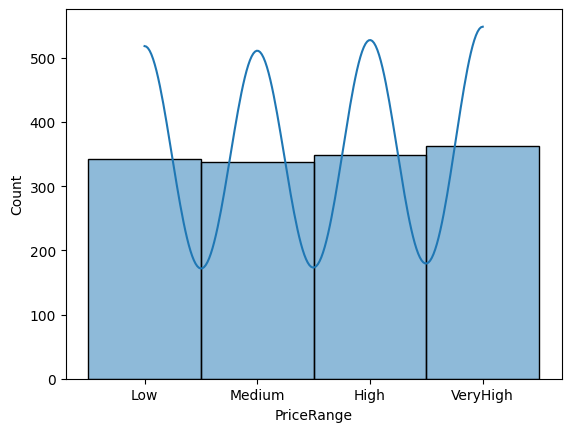

In [114]:
price_order = ["Low", "Medium", "High", "VeryHigh"]

mobile_data["PriceRange"] = pd.Categorical(mobile_data["PriceRange"],
                                           categories=price_order,
                                           ordered=True)

sns.histplot(mobile_data["PriceRange"], bins=30, kde=True)

In [115]:
for c in mobile_data.columns:
    print(f"\nColumn: {c}")
    print(mobile_data[c].value_counts().sort_index())



Column: BatteryPower
BatteryPower
501     2
502     2
503     2
504     3
506     1
       ..
1994    2
1995    2
1996    1
1997    1
1998    1
Name: count, Length: 894, dtype: int64

Column: InternalMemory
InternalMemory
2     29
3     19
4     15
5     23
6     31
      ..
60    18
61    19
62    17
63    21
64    19
Name: count, Length: 63, dtype: int64

Column: ClockSpeed
ClockSpeed
0.5    289
0.6     49
0.7     48
0.8     41
0.9     46
1.0     41
1.1     36
1.2     38
1.3     48
1.4     50
1.5     47
1.6     56
1.7     37
1.8     40
1.9     47
2.0     45
2.1     55
2.2     37
2.3     55
2.4     44
2.5     51
2.6     35
2.7     37
2.8     57
2.9     41
3.0     23
Name: count, dtype: int64

Column: NoOfCores
NoOfCores
1    179
2    171
3    170
4    178
5    178
6    162
7    177
8    178
Name: count, dtype: int64

Column: RAM
RAM
256     1
258     2
259     1
263     1
267     1
       ..
3971    1
3978    1
3991    2
3996    1
3998    1
Name: count, Length: 1174, dtype: int64

Co

In [117]:
mobile_data.duplicated()

,0
0,False
2,False
4,False
5,False
6,False
...,...
1992,False
1994,False
1997,False
1998,False


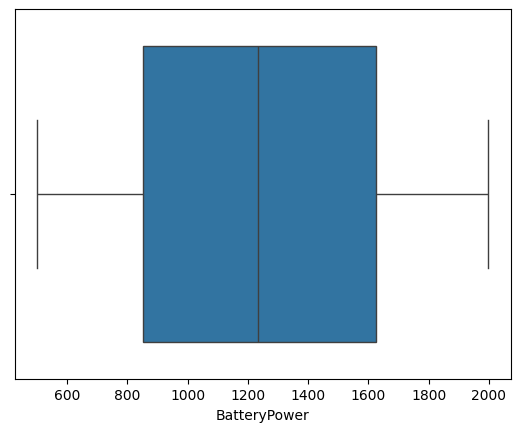

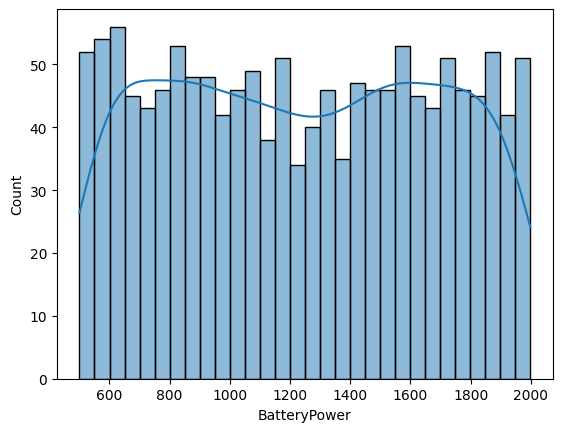

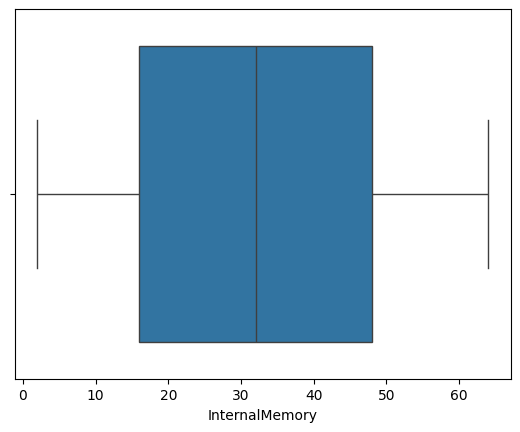

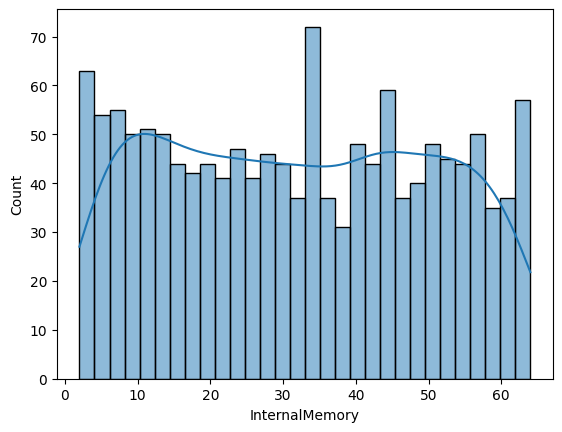

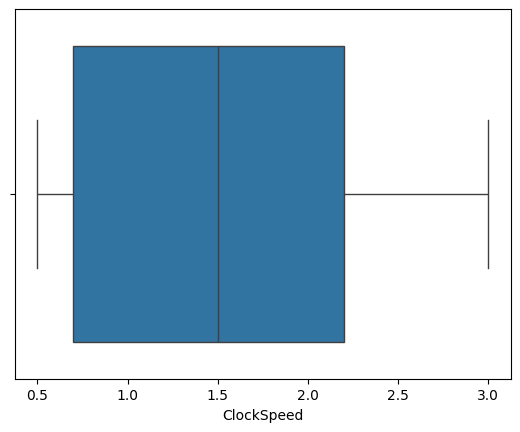

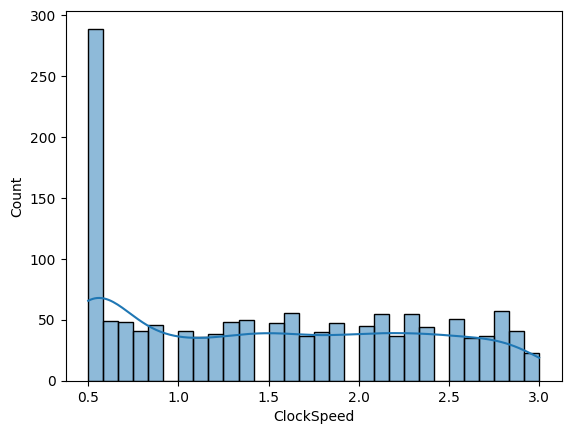

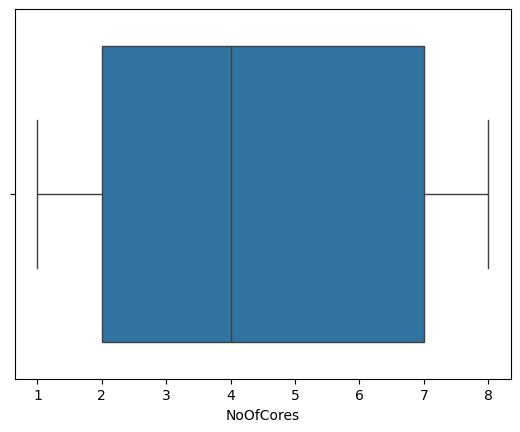

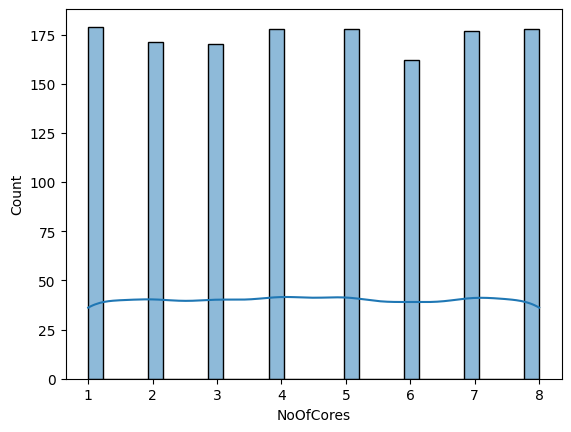

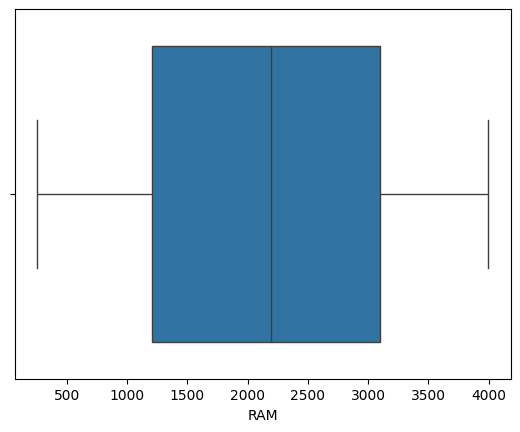

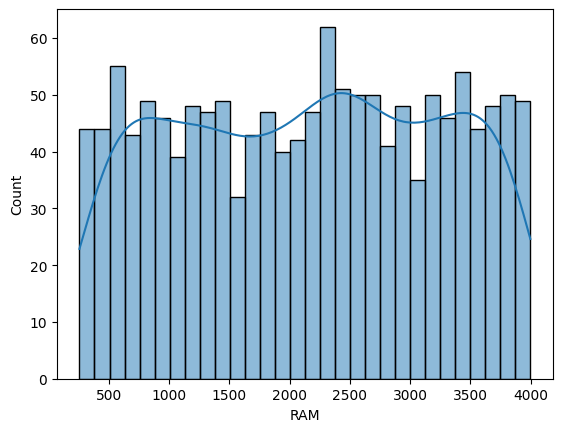

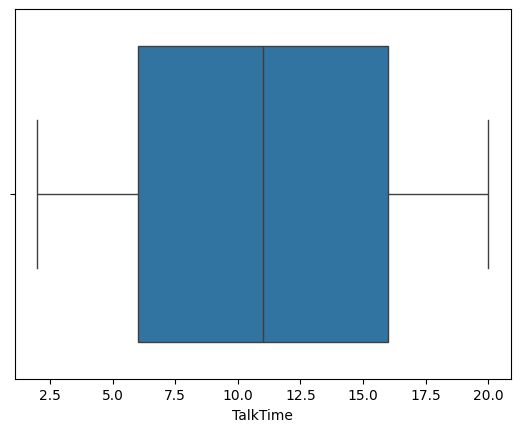

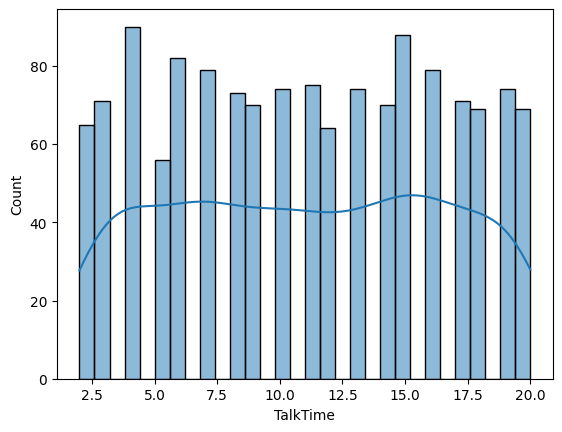

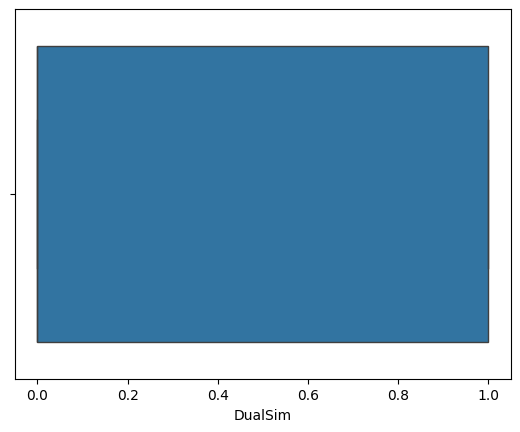

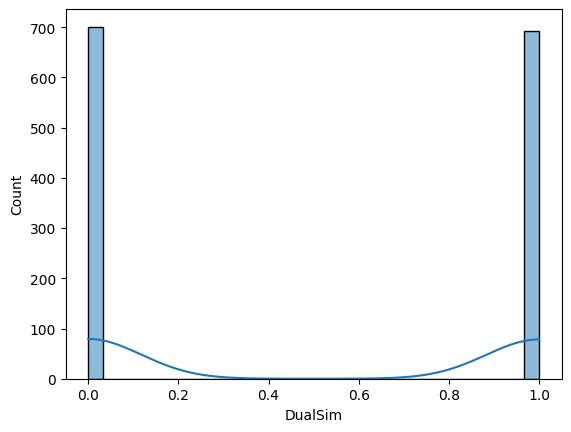

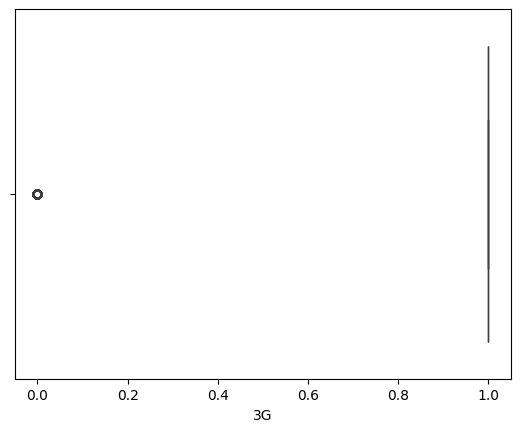

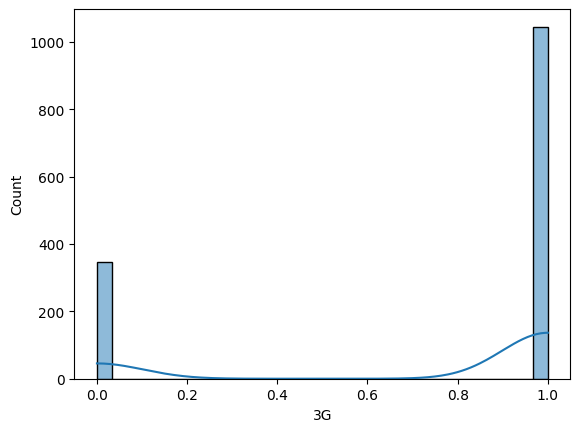

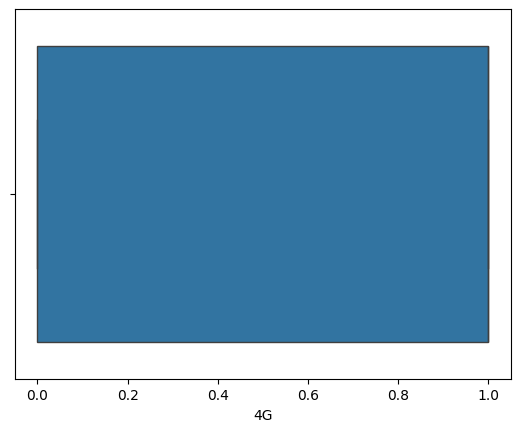

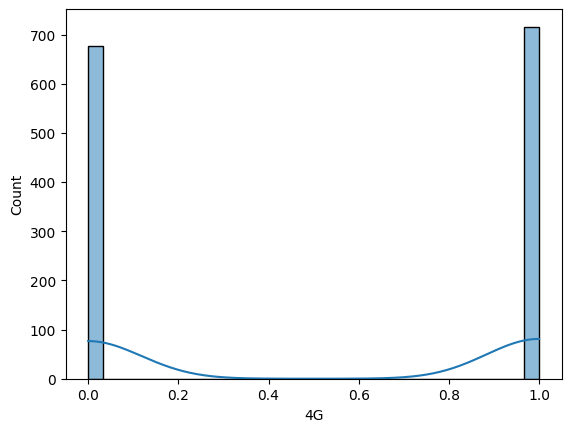

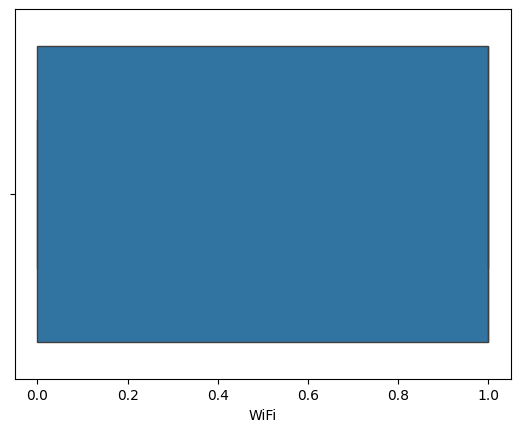

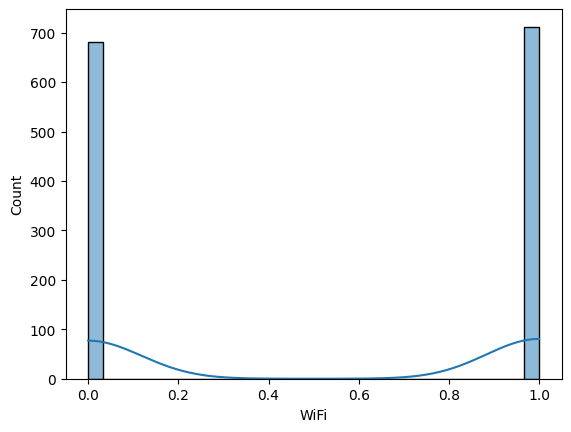

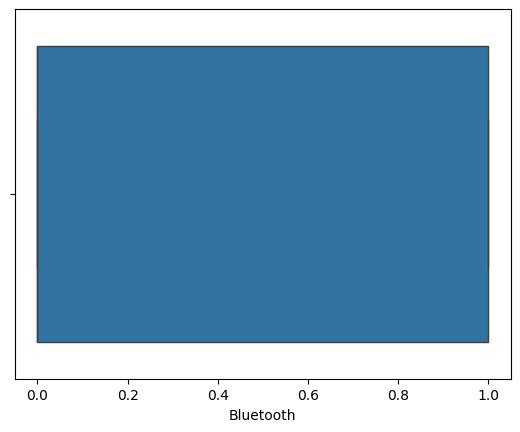

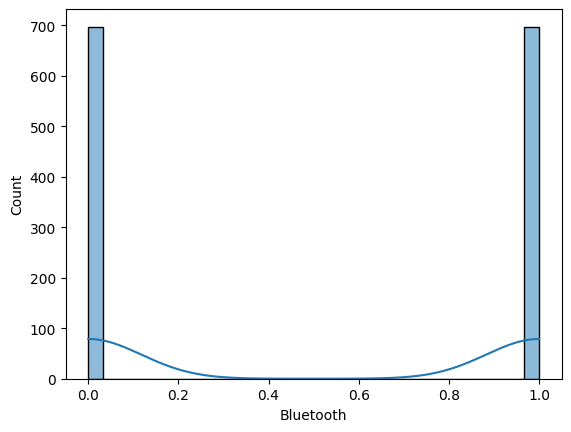

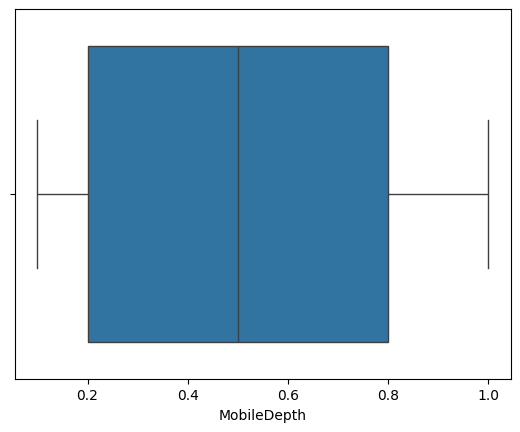

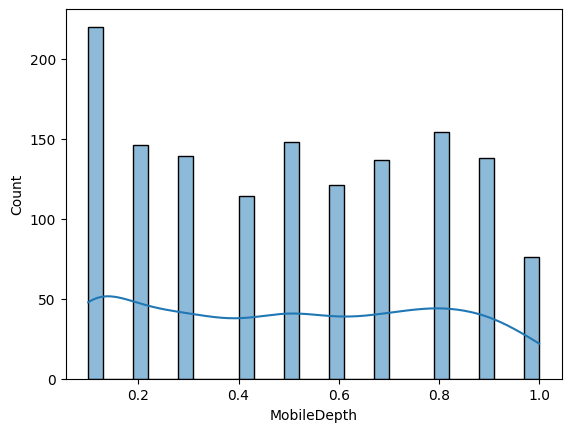

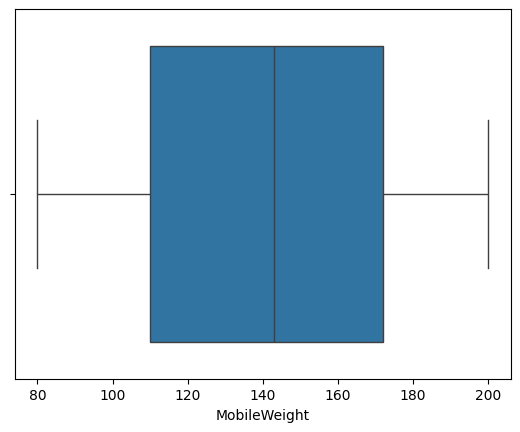

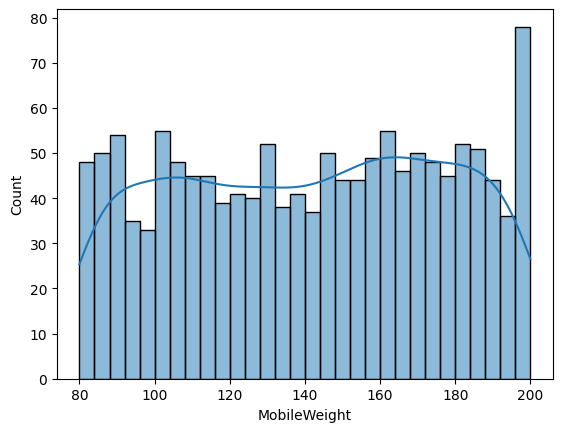

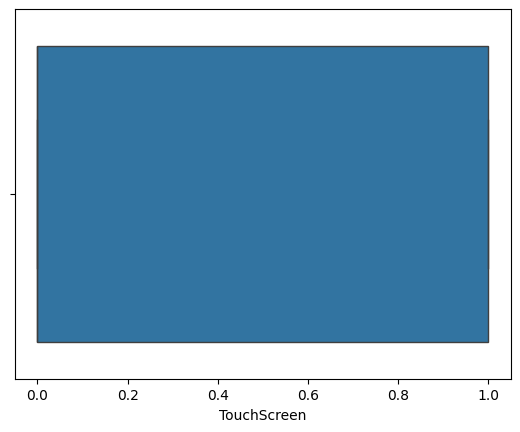

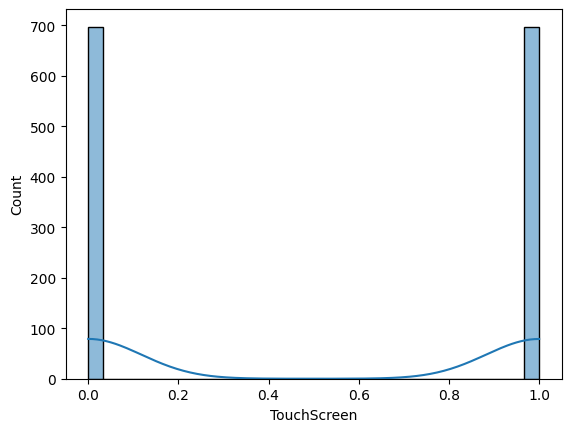

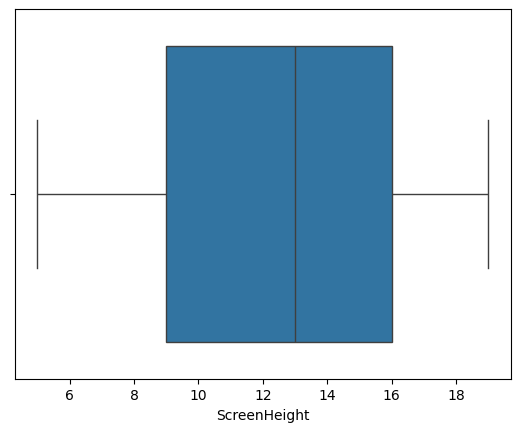

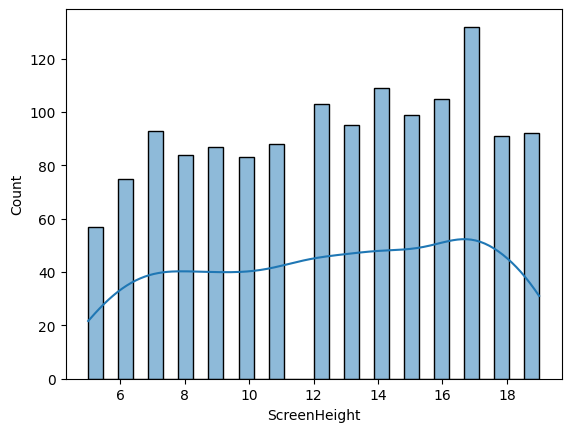

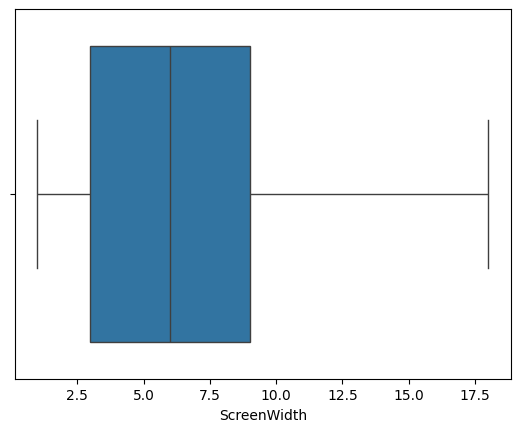

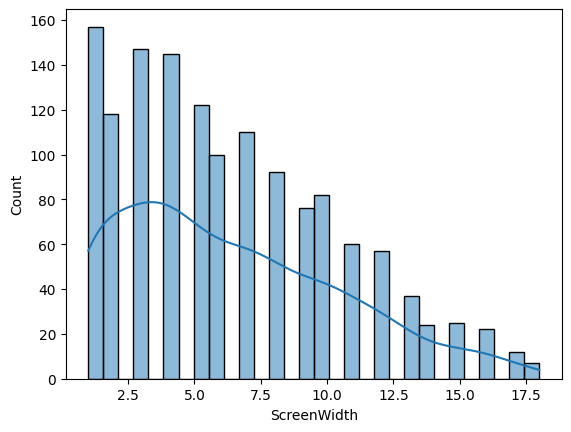

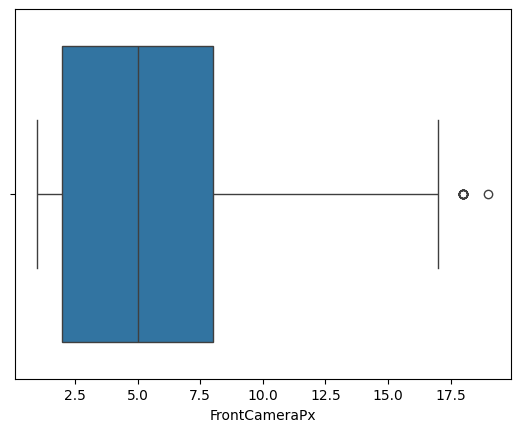

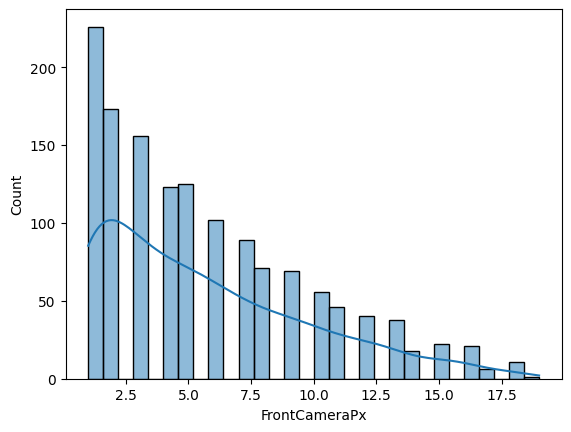

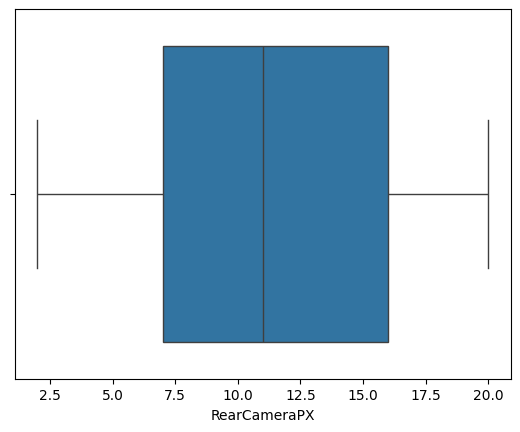

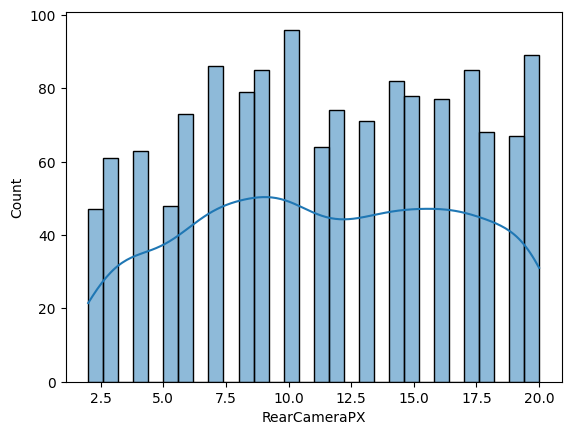

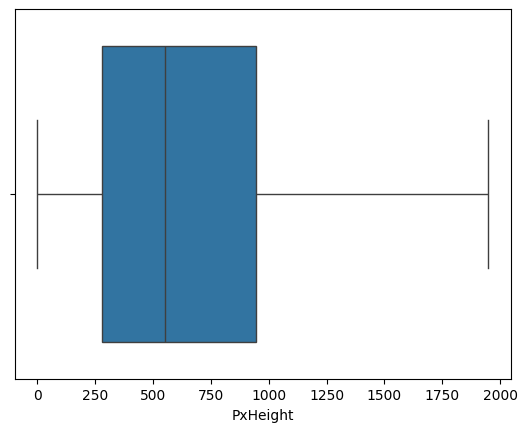

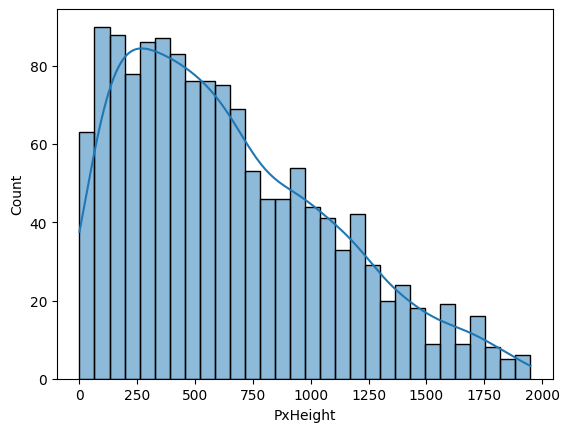

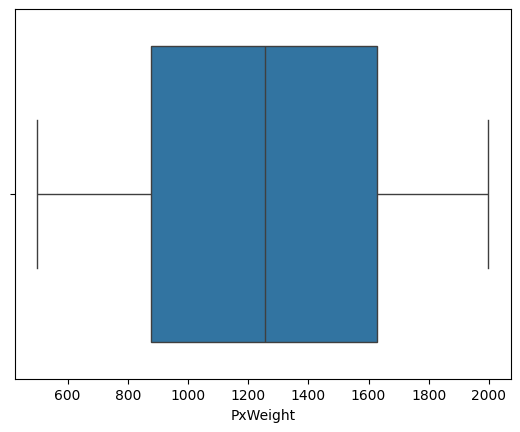

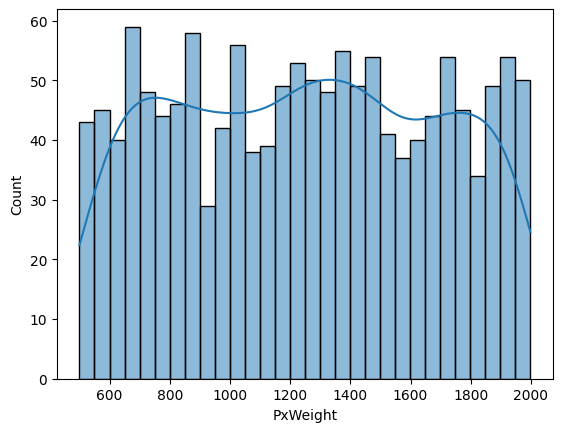

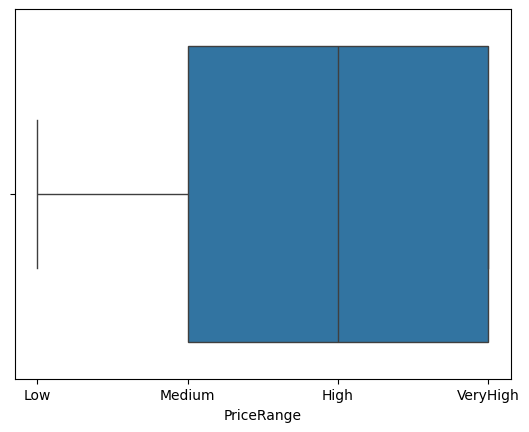

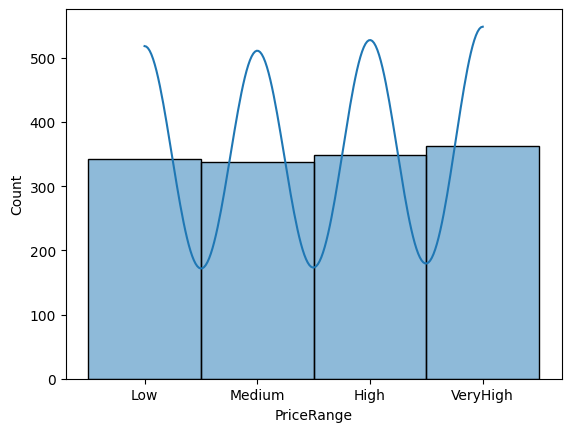

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in mobile_data.columns:
  sns.boxplot(x=mobile_data[col])
  plt.show()

  sns.histplot(mobile_data[col], bins=30, kde=True)
  plt.show()

## Exploratory Data Analysis

Columns with outliers: ['3G', 'FrontCameraPx']


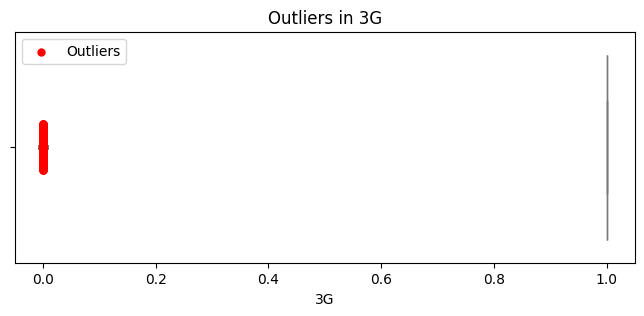

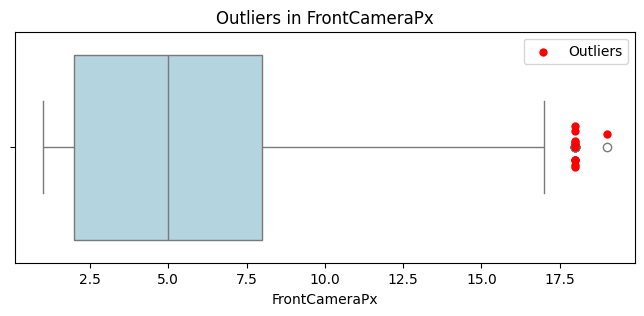

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get only the columns that actually have outliers
cols_with_outliers = [col for col, rows in outliers_dict.items() if len(rows) > 0]

print("Columns with outliers:", cols_with_outliers)

# Plot each outlier column
for col in cols_with_outliers:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col], color='lightblue')

    # Plot the outlier points on top
    sns.stripplot(x=outliers_dict[col][col], color='red', size=6, label="Outliers")

    plt.title(f"Outliers in {col}")
    plt.legend()
    plt.show()


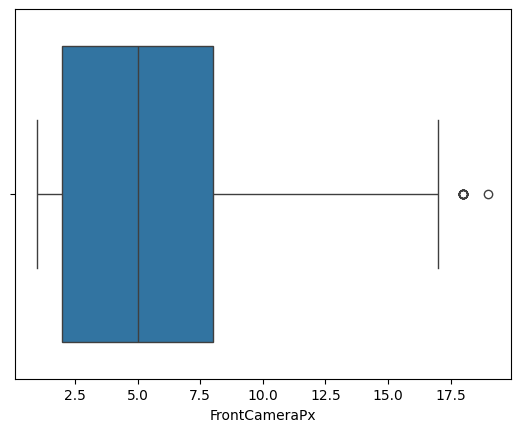

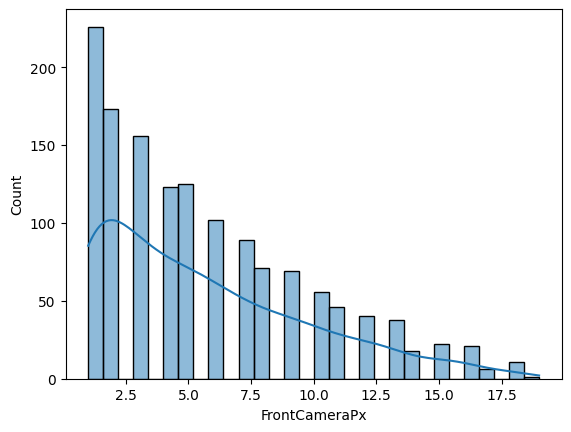

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["FrontCameraPx"])
plt.show()

sns.histplot(df["FrontCameraPx"], bins=30, kde=True)
plt.show()


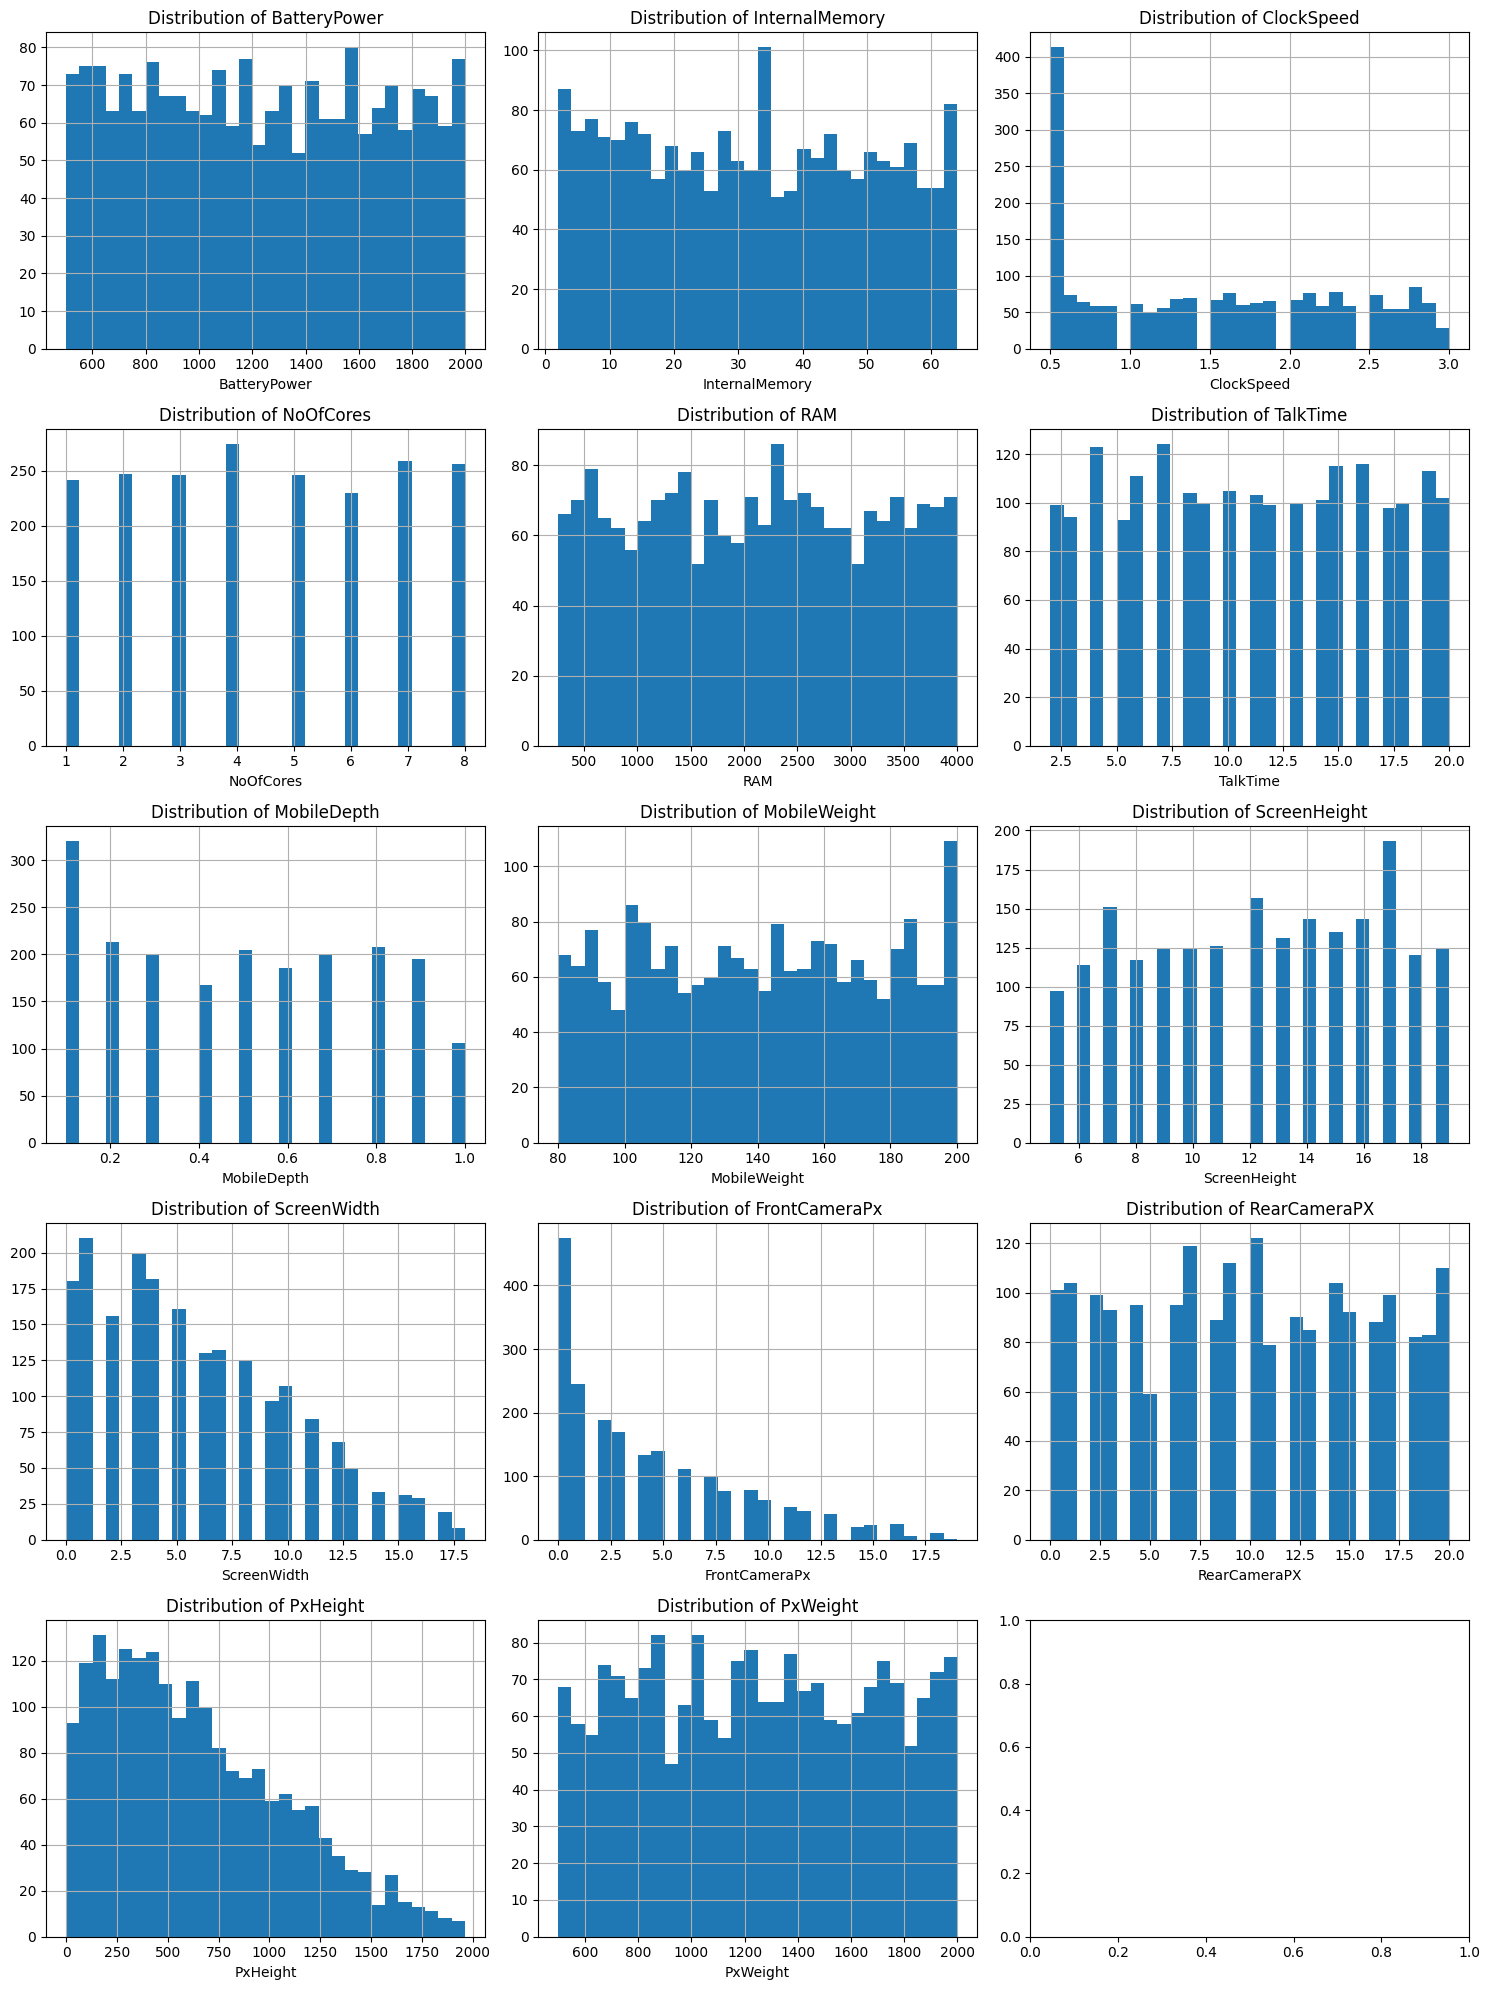

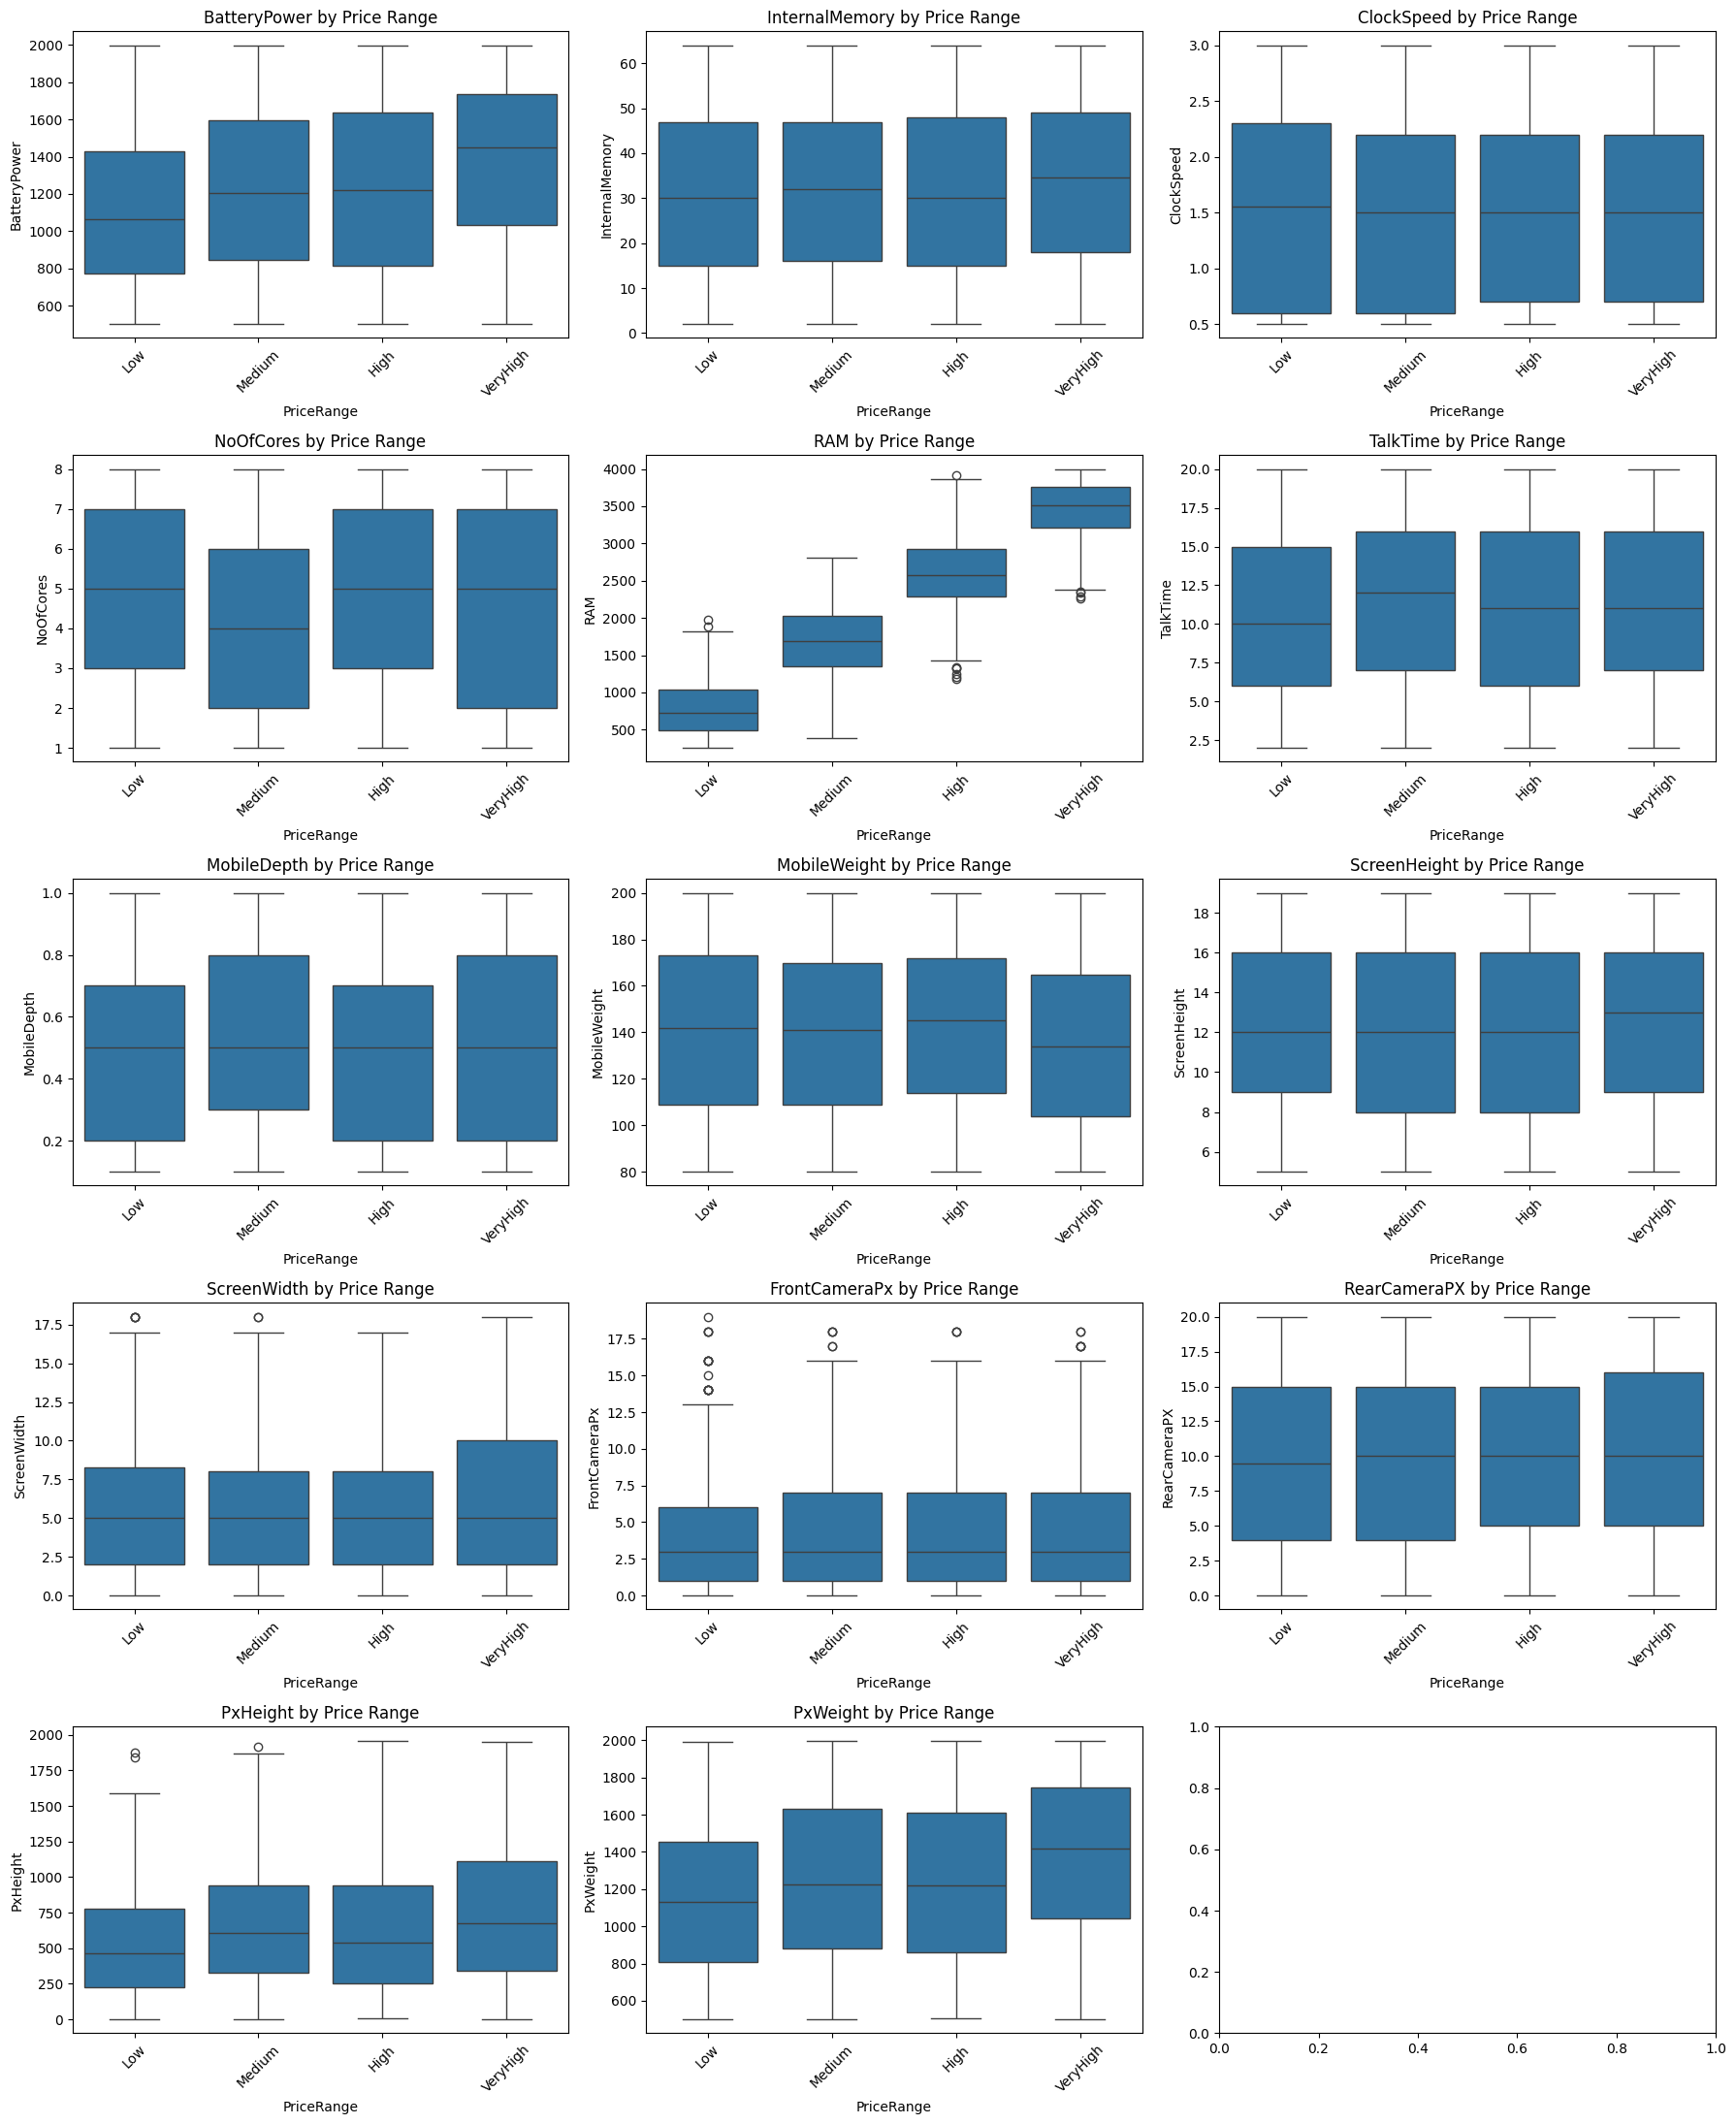

In [101]:
# Select numerical columns (excluding binary/categorical)
numerical_cols = ['BatteryPower', 'InternalMemory', 'ClockSpeed', 'NoOfCores',
                 'RAM', 'TalkTime', 'MobileDepth', 'MobileWeight',
                 'ScreenHeight', 'ScreenWidth', 'FrontCameraPx', 'RearCameraPX',
                 'PxHeight', 'PxWeight']

# Distribution plots
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    mobile_data[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Boxplots by PriceRange
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=mobile_data, x='PriceRange', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Price Range')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## K-NN model

Best k: 17


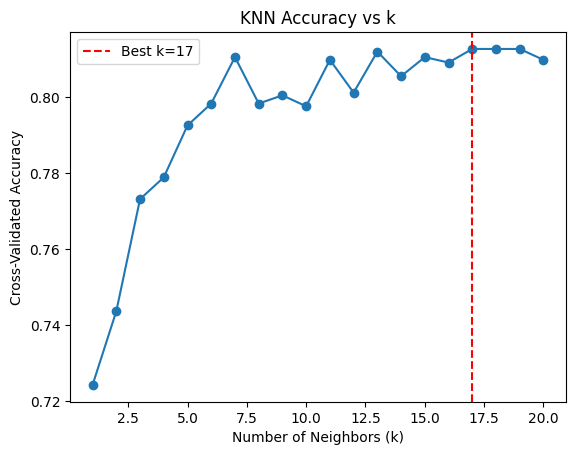

In [119]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=5).mean()
    scores.append(score)

best_k = k_range[np.argmax(scores)]
print("Best k:", best_k)

plt.plot(k_range, scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Accuracy vs k")
plt.axvline(best_k, color='r', linestyle='--', label=f"Best k={best_k}")
plt.legend()
plt.show()


In [122]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]


X_train, X_test, y_train, y_test = train_test_split( # 80 - 20
    X, y, test_size=0.2, random_state=42, stratify=y
)

k = 17
print(f"Using k = {k} for the k-NN model.")

knn_model = KNeighborsClassifier(n_neighbors=k)


knn_model.fit(X_train, y_train)
print("k-NN model trained successfully.")

y_pred_knn = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("-" * 30)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")
print("-" * 30)

Using k = 17 for the k-NN model.
k-NN model trained successfully.
------------------------------
Model Accuracy on Test Set: 0.8065
------------------------------


## Decision trees

In [123]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

print(f"Features used (X): {list(X.columns)}")
print(f"Target variable (y): {y.name}")
print(f"Number of samples: {len(mobile_data)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_classifier.fit(X_train, y_train)
print("\nDecision Tree model trained successfully (Eager learning complete: rules defined).")

y_pred_dt = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("-" * 60)
print(f"Decision Tree Accuracy on Test Set: {accuracy:.4f}")
print("-" * 60)

new_phone = pd.DataFrame([[3500, 4096]], columns=["BatteryPower", "RAM"])

prediction = dt_classifier.predict(new_phone)[0]
print(f"New phone (Battery: 3500, RAM: 4096) predicted PriceRange (0-3): {prediction}")

Features used (X): ['BatteryPower', 'RAM']
Target variable (y): PriceRange
Number of samples: 1393

Decision Tree model trained successfully (Eager learning complete: rules defined).
------------------------------------------------------------
Decision Tree Accuracy on Test Set: 0.8065
------------------------------------------------------------
New phone (Battery: 3500, RAM: 4096) predicted PriceRange (0-3): VeryHigh


## Tuned Decision Trees

In [127]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load and prepare data
X = mobile_data[["BatteryPower", "RAM"]]
y = mobile_data["PriceRange"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Perform grid search
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_knn = grid_search.best_estimator_

# Make predictions and evaluate
y_pred_rf = best_knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

# Results
print("🏆 Best Hyperparameters:", grid_search.best_params_)
print(f"📊 Test Accuracy: {accuracy:.4f}")
print(f"🎯 Cross-validation Score: {grid_search.best_score_:.4f}")

🏆 Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'uniform'}
📊 Test Accuracy: 0.8244
🎯 Cross-validation Score: 0.8097


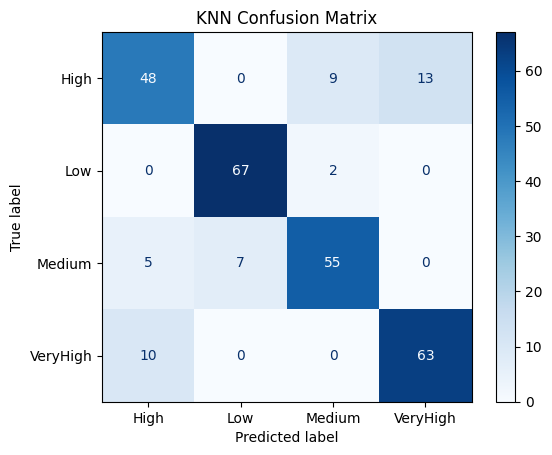

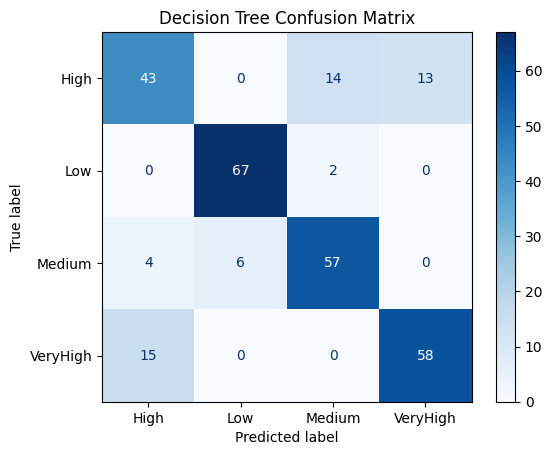

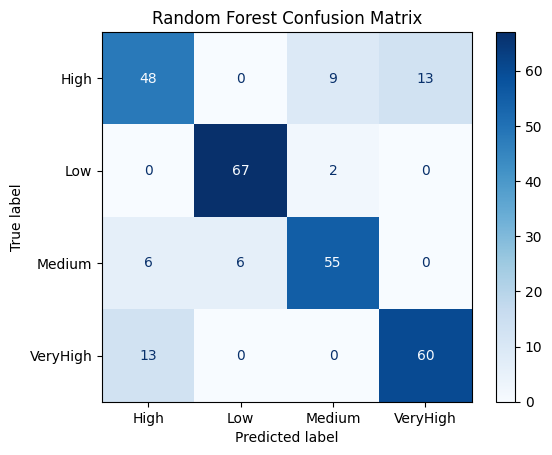

In [128]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
    disp.plot(cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()
